# -- Notebook 02: Analysis --

**Summary of the notebook:**

* Evaluating different models on their ability to predict collision_severity: 
    * A simple OLS regression
    * A LASSO model
    * A gradient-boosted decision tree
    * A feedforward neural network 
* Examining which ex-ante variable best predicts collision severity, making sure that ex-post variables (such as the different characteristics of those individuals who were injured) were not leaking back into the prediction model

In [ ]:
# Necessary libraries: 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_squared_error, accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
import xgboost
from xgboost import XGBClassifier
from statsmodels.miscmodels.ordinal_model import OrderedModel
import shap
from pathlib import Path

In [ ]:
# Importing datasets: 

base_path = Path(r"C:/Users/abhik/OneDrive/Desktop/WISE")
    # Again, edit this path as necessary
processed_path = base_path / "Data" / "Processed"
viz_path = Path(r"C:/Users/abhik/OneDrive/Desktop/WISE/Data/Dashboard/Visualisations")

X_train_full = pd.read_csv(processed_path / "X_train.csv")
X_test_full = pd.read_csv(processed_path / "X_test.csv")
y_train_full = pd.read_csv(processed_path / "y_train.csv")
y_test_full = pd.read_csv(processed_path / "y_test.csv")

In [ ]:
# Specifying predictor variables: 

predictors = ['location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 
              'day_of_week', 'hour', 'local_authority_district','first_road_class', 
              'road_type', 'speed_limit','vehicle_type', 'vehicle_left_hand_drive' , 
              'sex_of_driver', 'age_of_driver', 'driver_imd_decile' , 'engine_capacity_cc', 
              'propulsion_code', 'age_of_vehicle' , 'generic_make_model',
              'journey_purpose_of_driver_historic' , 'age_of_casualty', 'sex_of_casualty', 
              'casualty_type']

In [27]:
# Splitting the test/train data into the predictors and outcome: 

X_train = X_train_full[predictors]
y_train = y_train_full[['collision_severity']]

X_test = X_test_full[predictors]
y_test = y_test_full[['collision_severity']]

In [30]:
# Grouping rare categories in the high-cardinality columns before encoding:

def group_rare_categories(train_col, test_col, min_count=150):
    counts = train_col.value_counts()
    rare = counts[counts < min_count].index
    train_grouped = train_col.where(~train_col.isin(rare), 'RARE_CATEGORY')
    # Categories seen in the test set but not the (grouped) training set are also
    # mapped to 'RARE_CATEGORY', so OneHotEncoder never sees an unseen test category:
    test_grouped = test_col.where(test_col.isin(train_grouped.unique()), 'RARE_CATEGORY')
    return train_grouped, test_grouped

high_cardinality_cols = ['generic_make_model', 'local_authority_district']

X_train = X_train.copy()
X_test = X_test.copy()

for col in high_cardinality_cols:
    X_train[col], X_test[col] = group_rare_categories(X_train[col], X_test[col])
    
categorical_predictors = [
    'day_of_week', 'local_authority_district', 'first_road_class', 'road_type',
    'vehicle_type', 'sex_of_driver', 'propulsion_code', 'generic_make_model',
    'journey_purpose_of_driver_historic', 'sex_of_casualty', 'casualty_type'
]

for col in categorical_predictors:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [34]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

preprocessor = ColumnTransformer(transformers=[
     ('num', StandardScaler(), numeric_predictors),
     ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_predictors)
])

# --- ADD THIS LINE ---
preprocessor.set_output(transform="pandas")

# These will now naturally output as Pandas DataFrames!
X_train_scaled_df = preprocessor.fit_transform(X_train)
X_test_scaled_df = preprocessor.transform(X_test)

In [ ]:
# # Encoding categorical predictors and scaling/normalising continuous ones: 

# categorical_predictors = [
#     'day_of_week', 'local_authority_district', 'first_road_class', 'road_type',
#     'vehicle_type', 'sex_of_driver', 'propulsion_code', 'generic_make_model',
#     'journey_purpose_of_driver_historic', 'sex_of_casualty', 'casualty_type'
# ]

# for col in categorical_predictors:
#     X_train[col] = X_train[col].astype(str)
#     X_test[col] = X_test[col].astype(str)
    
# numeric_predictors = [p for p in predictors if p not in categorical_predictors]

# preprocessor = ColumnTransformer(transformers=[
#     ('num', StandardScaler(), numeric_predictors),
#     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_predictors)
# ])

# X_train_scaled = preprocessor.fit_transform(X_train)
# X_test_scaled = preprocessor.transform(X_test)

# feature_names = preprocessor.get_feature_names_out()

# X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
# X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

In [35]:
# Adjusting values of collision_severity: 

y_train = y_train - 1
y_test = y_test - 1

**Checking for class imbalance:**

Before comparing models on accuracy alone, it's worth checking how balanced the outcome classes are. UK collision data is typically skewed heavily toward 'slight' injury collisions relative to 'serious' or 'fatal' ones — if that's the case here, a model can score high accuracy just by mostly predicting the majority class. We track balanced accuracy and macro-F1 alongside plain accuracy throughout, since both give equal weight to each class regardless of its size.

collision_severity
0.0    0.019613
1.0    0.221846
2.0    0.758540
Name: proportion, dtype: float64


<Axes: title={'center': 'Class distribution (training set)'}, xlabel='collision_severity (0=Fatal, 1=Serious, 2=Slight)', ylabel='Count'>

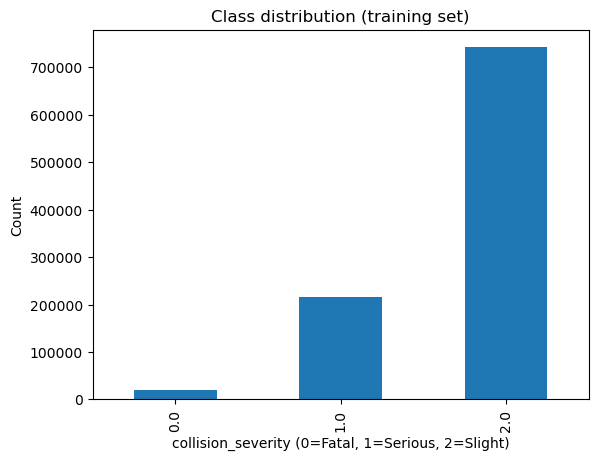

In [38]:
print(y_train['collision_severity'].value_counts(normalize=True).sort_index())

y_train['collision_severity'].value_counts().sort_index().plot(
    kind='bar',
    title='Class distribution (training set)',
    xlabel='collision_severity (0=Fatal, 1=Serious, 2=Slight)',
    ylabel='Count'
)

**OLS Regression:**

In [39]:
# Creating the model: 
ols = LinearRegression()

# Fitting model on training data: 
ols.fit(X_train_scaled_df, y_train)

# Generating predictions on test_data: 
y_pred_ols = ols.predict(X_test_scaled_df)

*Evaluating model performance:*

In [40]:
# Using Out-Of-Sample R^2: 

def oos_r2(y_true, y_pred, y_train_mean): 
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_train_mean)**2)
    
    return 1 - ss_res/ ss_tot

train_mean = y_train.mean().item()

# Calculating OOS R^2 for OLS: 

r2_ols = oos_r2(y_test.values, y_pred_ols, train_mean)
print(r2_ols)

-0.022764854104241117


In [41]:
# Using MSE: 

from sklearn.metrics import mean_squared_error

# Calculate MSE
mse_ols = mean_squared_error(y_test.values, y_pred_ols)
print(mse_ols)

0.2522756150002055


**LASSO Regression:**

In [42]:
lasso = Lasso(alpha = 5)
lasso.fit(X_train_scaled_df, y_train)
train_score_lasso = lasso.score(X_train_scaled_df, y_train)
test_score_ls = lasso.score(X_test_scaled_df, y_test)

print(test_score_ls)


0.00048427778563853163


<Axes: >

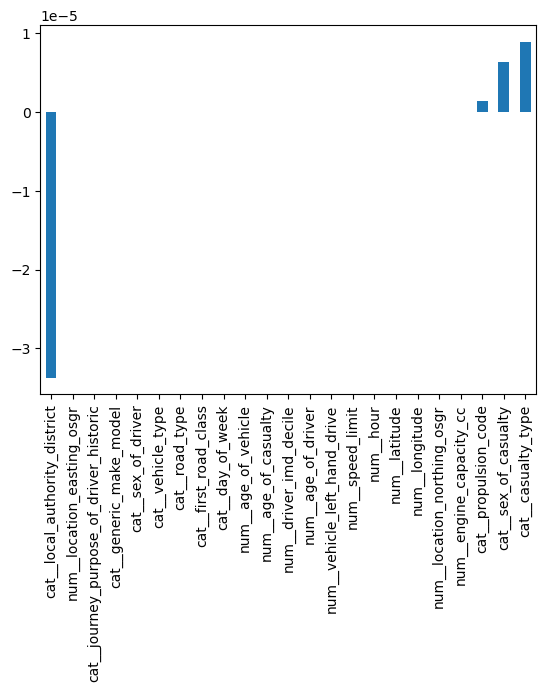

In [43]:
pd.Series(lasso.coef_, X_train_scaled_df.columns).sort_values(ascending = True).plot(kind = 'bar')

Here, we see that setting the penalty to an arbitrary number that is too high can result in the LASSO model setting quite a few coefficients to 0. 

In [ ]:
y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

In [49]:
# Selecting optimal penalty using cross-validation: 

lasso_cv = LassoCV(alphas = [0.0001, 0.001,0.01, 0.1, 1, 10], random_state=0, max_iter = 5000).fit(X_train_scaled_df, y_train_flat)


In [50]:
print(lasso_cv.score(X_test_scaled_df, y_test))

-0.02922834942656305


<Axes: >

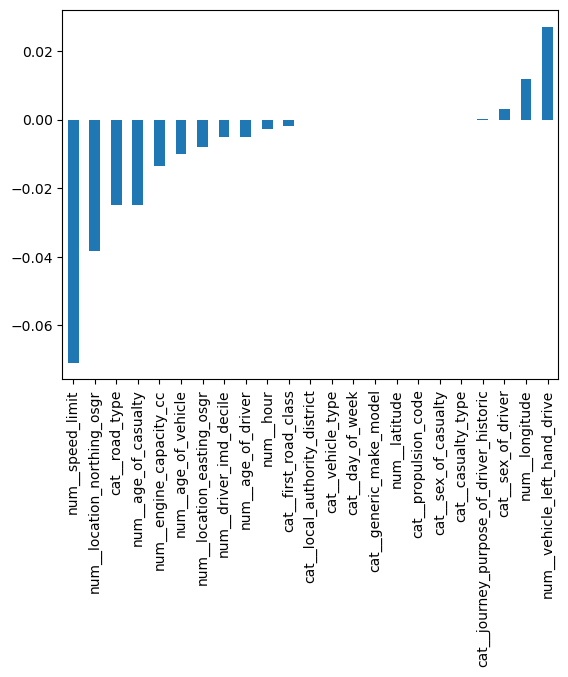

In [51]:
pd.Series(lasso_cv.coef_, X_train_scaled_df.columns).sort_values(ascending = True).plot(kind = 'bar')

**Gradient-Boosted Decision Tree**

In [54]:
# Create the model
gradtree = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,      # Equivalent to n_estimators in GradientBoostingClassifier
    max_depth=3,
    random_state=42
)

# Train the model
gradtree.fit(X_train_scaled_df, y_train['collision_severity'])

# Make predictions
y_pred = gradtree.predict(X_test_scaled_df)

# Evaluate
print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred))


Accuracy: 0.7351163946614964

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.01      0.02      4985
           1       0.59      0.02      0.04     60102
           2       0.74      1.00      0.85    178352

    accuracy                           0.74    243439
   macro avg       0.64      0.34      0.30    243439
weighted avg       0.70      0.74      0.63    243439



In [57]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_iter": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_search = GridSearchCV(
    estimator=gradtree,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy"     
)

# Fit
grid_search.fit(X_train_scaled_df, y_train['collision_severity'])

# Results
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}
Best CV accuracy: 0.7678258790658737


In [60]:
# Model with updated parameters: 
gradtree = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,      # Equivalent to n_estimators in GradientBoostingClassifier
    max_depth=5,
    random_state=42
)

# Train the model
gradtree.fit(X_train_scaled_df, y_train['collision_severity'])

# Make predictions
y_pred = gradtree.predict(X_test_scaled_df)

# Evaluate
print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred))

Accuracy: 0.7279030886587605

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.01      0.03      4985
           1       0.44      0.12      0.18     60102
           2       0.75      0.95      0.84    178352

    accuracy                           0.73    243439
   macro avg       0.45      0.36      0.35    243439
weighted avg       0.66      0.73      0.66    243439



In [61]:
from sklearn.inspection import permutation_importance

<Axes: title={'center': 'Variable Importance Plot'}, xlabel='Importance', ylabel='Variables'>

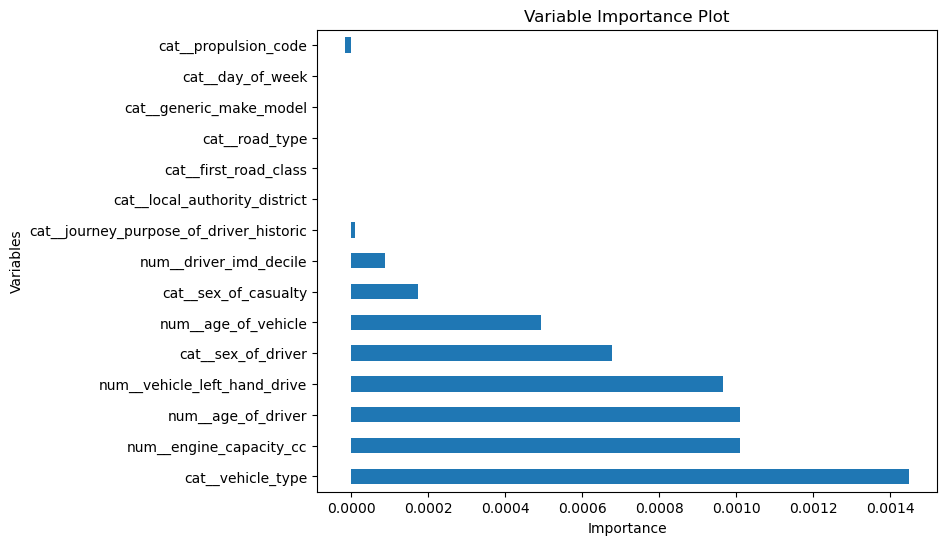

In [65]:
y_test_full = y_test['collision_severity'].squeeze()

# 2. Compute permutation importance on the entire test dataset
result = permutation_importance(
    gradtree,
    X_test_scaled_df,              # Swapped out sample for the full test dataframe
    y_test_full,                   # Swapped out sample for the full target values
    n_repeats=3,      
    random_state=42,
    n_jobs=1                       # Changed to 1 to prevent Windows resource allocation crashes
)

# 3. Map the results back to the feature column names
importance = pd.Series(
    result.importances_mean,
    index=X_train_scaled_df.columns
).sort_values(ascending = False)

# 4. Plot top 15 features
importance.tail(15).plot.barh(
    figsize=(8, 6), 
    title="Variable Importance Plot", 
    xlabel="Importance", 
    ylabel="Variables"
)

<Axes: title={'center': 'Variable Importance Plot'}, xlabel='Importance', ylabel='Variables'>

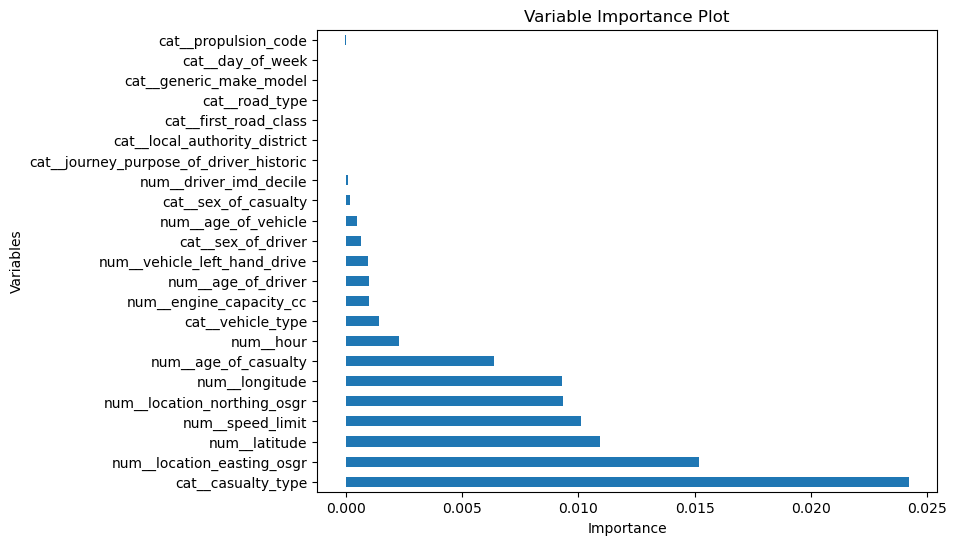

In [66]:
importance.head(30).plot.barh(
    figsize=(8, 6), 
    title="Variable Importance Plot", 
    xlabel="Importance", 
    ylabel="Variables"
)

The above plot shows us how much each variable contributed to the prediction of the outcome (collision severity). This shows us that variables like location, type of casualty, and type of vehicle are the strongest predictors of how severe the collision will be, with other variables like speed limit, age of casualty, and road type also playing a moderate influence. 

**Checking for potential leakage from casualty-level variables:**

`age_of_casualty`, `sex_of_casualty` and `casualty_type` describe the casualty *after* the collision has happened, and severity may be partly bound up with casualty type by definition (e.g. pedestrian casualties tend to have different injury profiles to car occupants, independent of anything about the collision itself). It's worth checking how much of the tree's predictive power comes from these variables specifically — if it's a lot, that's a sign we may partly be predicting the outcome from itself, rather than from genuine ex-ante risk factors known at the time of the collision.

In [ ]:
# leakage_suspects = ['num_age_of_casualty', 'num_sex_of_casualty', 'casualty_type']
# predictors_no_leakage = [p for p in predictors if p not in leakage_suspects]

# X_train_noleak = X_train_full[predictors_no_leakage]
# X_test_noleak = X_test_full[predictors_no_leakage]

# gradtree_noleak = HistGradientBoostingClassifier(
#     learning_rate=0.1,
#     max_iter=200,
#     max_depth=5,
#     random_state=42
# )
# gradtree_noleak.fit(X_train_noleak, y_train['collision_severity'])
# y_pred_noleak = gradtree_noleak.predict(X_test_noleak)

# print("Accuracy with casualty variables:   ",
#       accuracy_score(y_test['collision_severity'], gradtree.predict(X_test)))
# print("Accuracy without casualty variables:",
#       accuracy_score(y_test['collision_severity'], y_pred_noleak))

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

leakage_suspects = ['num_age_of_casualty', 'num_sex_of_casualty', 'casualty_type']
predictors_no_leakage = [p for p in predictors if p not in leakage_suspects]

X_train_noleak = X_train_full[predictors_no_leakage]
X_test_noleak = X_test_full[predictors_no_leakage]

# 1. Dynamically split your new no-leak predictors by type
numeric_noleak = [p for p in X_train_noleak.columns if p not in categorical_predictors]
cat_noleak = [p for p in X_train_noleak.columns if p in categorical_predictors]

# 2. Re-enforce clean string data types to prevent previous mixed-type errors
for col in cat_noleak:
    X_train_noleak[col] = X_train_noleak[col].fillna("Missing").astype(str)
    X_test_noleak[col] = X_test_noleak[col].fillna("Missing").astype(str)

# 3. Create a clean no-leak pipeline transformer
preprocessor_noleak = ColumnTransformer(transformers=[
     ('num', StandardScaler(), numeric_noleak),
     ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_noleak)
])
preprocessor_noleak.set_output(transform="pandas")

# 4. Transform the data into clean numerical DataFrames
X_train_noleak_encoded = preprocessor_noleak.fit_transform(X_train_noleak)
X_test_noleak_encoded = preprocessor_noleak.transform(X_test_noleak)

# 5. Initialize your model
gradtree_noleak = HistGradientBoostingClassifier(
     max_iter=200,
     max_depth=5,
     random_state=42
)

# 6. Fit the model using the encoded numerical features and flatten the target array
gradtree_noleak.fit(X_train_noleak_encoded, y_train['collision_severity'].squeeze())

# 7. Make predictions safely
y_pred_noleak = gradtree_noleak.predict(X_test_noleak_encoded)

In [ ]:
print("Accuracy with casualty variables:    ",
       accuracy_score(y_test['collision_severity'], gradtree.predict(X_test_scaled_df))) 

print("Accuracy without casualty variables:",
       accuracy_score(y_test['collision_severity'], y_pred_noleak))

Accuracy with casualty variables:     0.7279030886587605
Accuracy without casualty variables: 0.7250194093797625


<Axes: title={'center': 'Variable Importance Plot (Without Casualty Leakage)'}, xlabel='Importance', ylabel='Variables'>

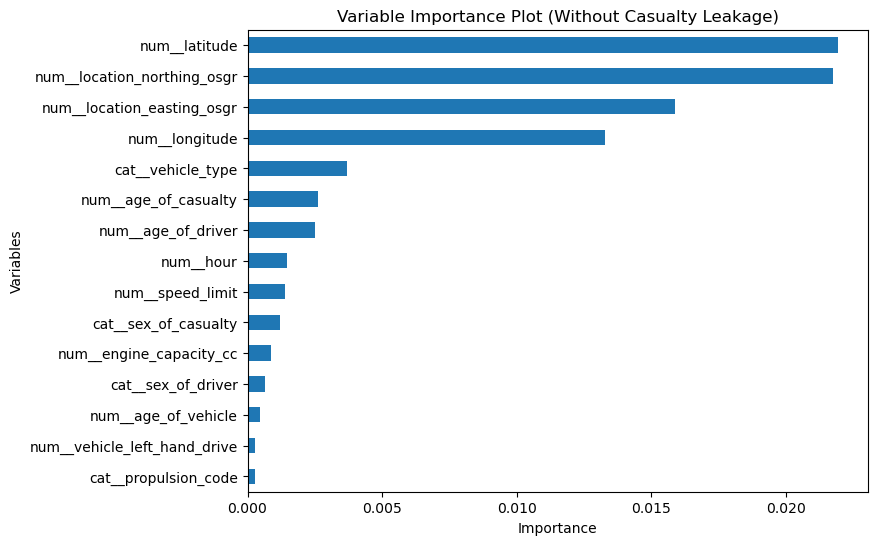

In [73]:
# 1. Extract the true target labels for the no-leak dataset
y_test_full_noleak = y_test['collision_severity'].squeeze()

# 2. Compute permutation importance using the no-leak model and encoded data
result_noleak = permutation_importance(
    gradtree_noleak, 
    X_test_noleak_encoded, 
    y_test_full_noleak,       # Fixed: Used true test targets instead of model predictions
    n_repeats=3, 
    random_state=42,
    n_jobs=1
)

# 3. Map the results back to the corrected no-leak feature columns
importance_noleak = pd.Series(
    result_noleak.importances_mean,
    index=X_train_noleak_encoded.columns # Fixed: Used the no-leak column index
).sort_values()                          # Kept default ascending sort so tail(15) plots highest on top

# 4. Plot top 15 features without casualty variables
importance_noleak.tail(15).plot.barh(    # Fixed: Changed from 'importance' to 'importance_noleak'
    figsize=(8, 6), 
    title="Variable Importance Plot (Without Casualty Leakage)", 
    xlabel="Importance", 
    ylabel="Variables"
)

A meaningful drop in accuracy once these variables are removed suggests they're doing a lot of the predictive work. That's worth flagging as a limitation — or reframing the research question as "predicting severity from information available at the scene" and excluding these variables from the headline model, rather than treating them as freely available ex-ante predictors.

**Feedforward Neural Network (Multi-Layer Perceptron):**

As a further non-linear benchmark, we fit a feedforward neural network (a Multi-Layer Perceptron, or MLP) trained via backpropagation. Like the OLS and LASSO models above, MLPs are sensitive to feature scale, so we reuse the standardised predictors (`X_train_scaled_df` / `X_test_scaled_df`) rather than the raw ones used for the tree models.

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
# Creating the model:

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# This code creates a neural network with two hidden layers of 64 and 32 neurons, using the ReLU activation function 
# The early_stopping argument essentially means that it stops training the model once it stops improving 

# Fitting model on scaled training data:
mlp.fit(X_train_scaled_df, y_train['collision_severity'])

# Generating predictions on test data:
y_pred_mlp = mlp.predict(X_test_scaled_df)

*Evaluating model performance:*

In [75]:
print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred_mlp))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred_mlp))

Accuracy: 0.7346234580326078

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.01      0.02      4985
           1       0.57      0.02      0.04     60102
           2       0.74      1.00      0.85    178352

    accuracy                           0.73    243439
   macro avg       0.54      0.34      0.30    243439
weighted avg       0.69      0.73      0.63    243439



*Inspecting training behaviour:*

Plotting the loss curve is a useful diagnostic: if it hasn't flattened out, the network may be under-trained (increase `max_iter`); if training loss keeps falling while validation accuracy stalls or worsens, that's a sign of overfitting.

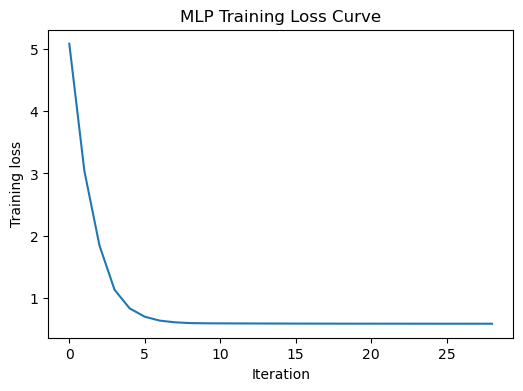

In [76]:
plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('MLP Training Loss Curve')
plt.show()

*Hyperparameter tuning:*

As with the gradient-boosted tree, we use a small grid search over network size and regularisation strength. Neural networks have many more possible hyperparameters (learning rate, number of layers, batch size, etc.) — this grid keeps things manageable, but feel free to expand it.

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid_mlp = {
    'hidden_layer_sizes': [(32,), (64, 32), (64, 32, 16)],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
    param_grid=param_grid_mlp,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_mlp.fit(X_train_scaled_df, y_train['collision_severity'])

print("Best parameters:", grid_search_mlp.best_params_)
print("Best CV accuracy:", grid_search_mlp.best_score_)

Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}
Best CV accuracy: 0.7614445190562082


In [78]:
# Refitting with the best parameters found above:
mlp_best = grid_search_mlp.best_estimator_
y_pred_mlp_best = mlp_best.predict(X_test_scaled_df)

print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred_mlp_best))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred_mlp_best))

Accuracy: 0.7346234580326078

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.01      0.02      4985
           1       0.57      0.02      0.04     60102
           2       0.74      1.00      0.85    178352

    accuracy                           0.73    243439
   macro avg       0.54      0.34      0.30    243439
weighted avg       0.69      0.73      0.63    243439



*Variable importance for the neural network:*

Neural networks don't have built-in coefficients or feature importances the way linear models or trees do, so we use the same permutation importance approach applied to the gradient-boosted tree above: shuffle one predictor at a time and see how much test accuracy drops.

<Axes: title={'center': 'MLP Variable Importance Plot'}, xlabel='Importance', ylabel='Variables'>

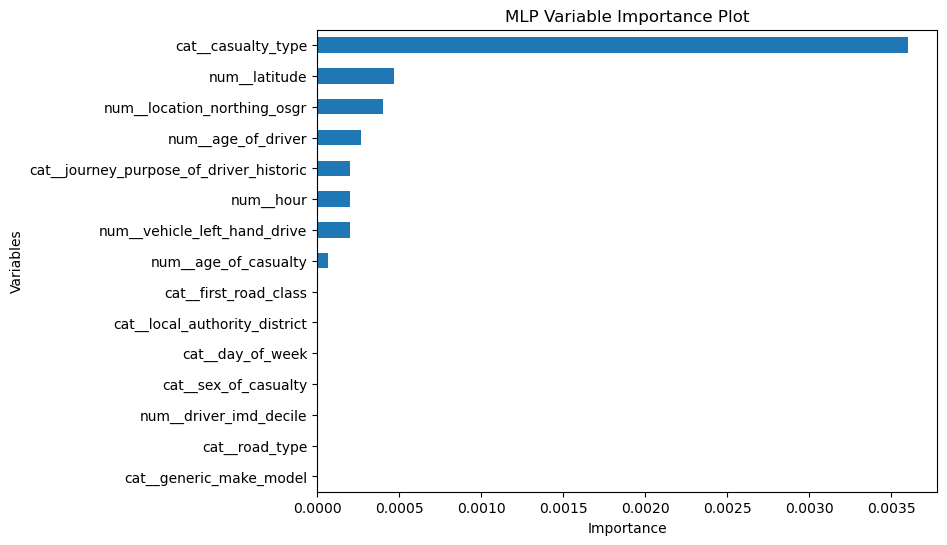

In [79]:
# Using a smaller sample of test data for faster calculation:
X_test_sample_mlp = X_test_scaled_df.sample(
    n=min(5000, len(X_test_scaled_df)),
    random_state=42
)

y_test_sample_mlp = y_test.loc[X_test_sample_mlp.index, 'collision_severity']

result_mlp = permutation_importance(
    mlp_best,
    X_test_sample_mlp,
    y_test_sample_mlp,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance_mlp = pd.Series(
    result_mlp.importances_mean,
    index=X_train_scaled_df.columns
).sort_values()

# Plotting top 15 features:
importance_mlp.tail(15).plot.barh(
    figsize=(8, 6),
    title="MLP Variable Importance Plot",
    xlabel="Importance",
    ylabel="Variables"
)

We see that the FNN and the gradient-boosted tree broadly agree on which variables matter most, which is reassuring evidence that those variables are genuinely predictive of collision severity, rather than being the result of one particular model's assumptions.

**Comparing all models:**

*Robustness: k-fold cross-validation*

A single train/test split — even a sensible chronological one, as used here — can be noisy. Repeating the split via cross-validation on the training data gives a sense of how much the accuracy estimates above might vary if we'd happened to split the data differently.

In [81]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    HistGradientBoostingClassifier(learning_rate=0.1, max_iter=200, max_depth=5, random_state=42),
    X_train_scaled_df,
    y_train['collision_severity'],
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("CV accuracy (gradient-boosted tree):", cv_scores.mean().round(3), "+/-", cv_scores.std().round(3))

CV accuracy (gradient-boosted tree): 0.769 +/- 0.001


*Explainability: SHAP values*

Permutation importance tells us how much each variable matters overall, but not the direction of its effect. SHAP values decompose each individual prediction into a contribution from each feature, which complements what we see from the permutation importance plots. 

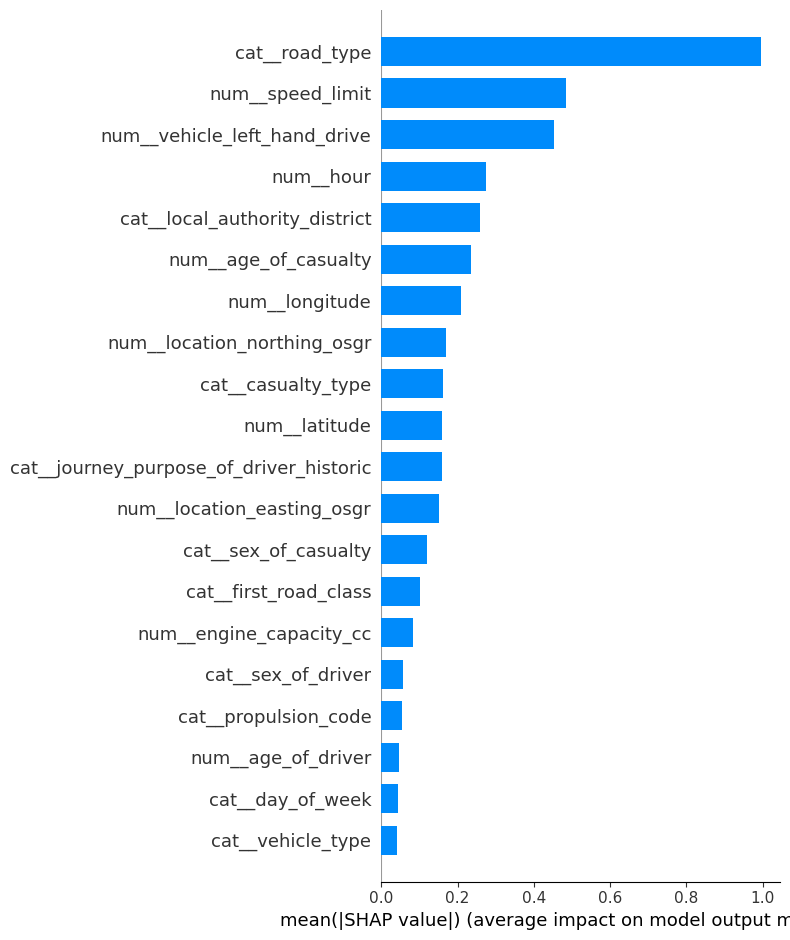

In [ ]:
explainer = shap.TreeExplainer(gradtree)

X_test_sample_shap = X_test_scaled_df.sample(n=min(2000, len(X_test_scaled_df)), random_state=42)
shap_values = explainer.shap_values(X_test_sample_shap)

*Comparing all models:*

Given that we saw the class imbalance earlier (i.e. that a lot of the collision_severity values are categorised as "Slight"), balanced accuracy and macro-F1 are reported alongside standard accuracy. OLS and LASSO are excluded, since they were fit as regressions on a continuous target rather than as classifiers, so these particular metrics aren't a fair comparison for them — their OOS R² and MSE are reported separately above.)

In [98]:
model_predictions = {
    'Gradient-Boosted Tree': gradtree.predict(X_test_scaled_df),
    'Gradient-Boosted Tree (no casualty vars)': y_pred_noleak,
    'Feedforward Neural Network': y_pred_mlp_best,
}

comparison_rows = []
for name, preds in model_predictions.items():
    comparison_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test['collision_severity'], preds),
        'Balanced Accuracy': balanced_accuracy_score(y_test['collision_severity'], preds),
        'Macro F1': f1_score(y_test['collision_severity'], preds, average='macro'),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index('Model')
    .sort_values('Balanced Accuracy', ascending=False)
)
print(model_comparison.round(3))

                                          Accuracy  Balanced Accuracy  \
Model                                                                   
Gradient-Boosted Tree                        0.728              0.361   
Gradient-Boosted Tree (no casualty vars)     0.725              0.346   
Feedforward Neural Network                   0.735              0.342   

                                          Macro F1  
Model                                               
Gradient-Boosted Tree                        0.350  
Gradient-Boosted Tree (no casualty vars)     0.319  
Feedforward Neural Network                   0.302  


We see that the FNN has the superior performance in predicting collision severity! We also see that when removing potentially ex-post variables from the dataset, the accuracy of the gradient boosted decision tree reduced slightly, but not substantially, insicating that the tree was not overfit on the casualty variables alone. 